In [35]:
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt

seed = 5
np.random.seed(seed)

result_path = Path("diagrams", "feature_weights_importances")
result_path.mkdir(exist_ok=True)

In [36]:
bias_type = "less_positive_class_comparison"
bias_strength = "0.1"
data_set_name = "breast_cancer"

In [37]:
feature_names = [
    "Clump Thickness",
    "Cell Size",
    "Cell Shape",
    "Marginal Adhesion",
    "Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",]

In [38]:
method_name = "fw-mrs-temperature-svm"
data_path = Path("..", "results", "downstream_task", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights/weights.json")
with open(data_path, 'r') as file:
    all_feature_weights_rf = json.load(file)

#data_path = Path("..", "results", "downstream_task", data_set_name, bias_type, bias_strength, 
#                 method_name, "feature_importances/feature_importances.json")
#with open(data_path, 'r') as file:
#    all_feature_importances_rf = json.load(file)

In [42]:
all_feature_weights_rf

[{'10.0': {'0.01': [0.1114773819384661,
    0.11182120705166233,
    0.11135764112064939,
    0.11045918886906232,
    0.11147847045222216,
    0.1102136803425414,
    0.11144122353335119,
    0.11051239152886018,
    0.11123881516318478],
   '0.1': [0.11160621299224166,
    0.11160381106975611,
    0.11130980792839038,
    0.11039194205113108,
    0.11151717665878234,
    0.11008470132681,
    0.11174402580278944,
    0.11044259808101105,
    0.11129972408908806],
   '1.0': [0.11163002531190026,
    0.11155049014488393,
    0.11128048943414387,
    0.11038500833433573,
    0.11153090883920795,
    0.1100761930960711,
    0.11179362676563288,
    0.11043958097922031,
    0.11131367709460406],
   '10.0': [0.11163262574178619,
    0.11154441816909412,
    0.11127693235936438,
    0.11038434586664271,
    0.11153254147914787,
    0.11007551227137884,
    0.11179892954211627,
    0.11043945354542392,
    0.11131524102504568],
   '100.0': [0.1116328882849314,
    0.11154380246305333,
    0.

In [39]:
hyperparameter = "0.01"
feature_weights_dict = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
#feature_importance_dict = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

feature_weights_dict_std = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
#feature_importance_dict_std = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

for temperature in all_feature_weights_rf[0].keys():
    for weights_values, importance_values in zip(all_feature_weights_rf, all_feature_importances_rf):
        weights_temperature_values = weights_values[temperature][hyperparameter]
        feature_weights_dict[temperature].append(weights_temperature_values)

        weights_importance_values = importance_values[temperature][hyperparameter]
        feature_importance_dict[temperature].append(weights_importance_values)

    feature_weights_dict_std[temperature] = np.std(feature_weights_dict[temperature], axis=0)
    feature_importance_dict_std[temperature] = np.std(feature_importance_dict[temperature], axis=0)
    
    feature_weights_dict[temperature] = np.mean(feature_weights_dict[temperature], axis=0)
    feature_importance_dict[temperature] = np.mean(feature_importance_dict[temperature], axis=0)


KeyError: '10.0'

In [41]:
weights_df = pd.DataFrame(feature_weights_dict).T
weights_df["Temperature"] = weights_df.index
weights_df.columns = feature_names +  ["Temperature"]
weights_df = pd.melt(weights_df, id_vars="Temperature")

importance_df = pd.DataFrame(feature_importance_dict).T
importance_df["Temperature"] = importance_df.index
importance_df = pd.melt(importance_df, id_vars="Temperature")

ValueError: All arrays must be of the same length

In [ ]:
feature_weights_dict_std

{'0.0': array([8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
        8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
        8.32667268e-17]),
 '0.1': array([0.05514918, 0.05519217, 0.05070504, 0.04834477, 0.05471786,
        0.05612728, 0.04787973, 0.05557193, 0.04409762]),
 '0.05': array([0.08606968, 0.08796146, 0.07572637, 0.08496596, 0.09314788,
        0.09340955, 0.08177693, 0.08916006, 0.08994744]),
 '0.01': array([0.20070931, 0.19045301, 0.14308772, 0.23205461, 0.24241173,
        0.19409431, 0.20659489, 0.20054029, 0.28598801]),
 '0.005': array([0.24246645, 0.22174545, 0.17802368, 0.27099337, 0.3115498 ,
        0.22244099, 0.23863343, 0.23219162, 0.35106053])}

In [ ]:
feature_weights_std_list = []
for i in range(9):
    feature_weights_std_list.extend(np.array(list(feature_weights_dict_std.values()))[:, i])

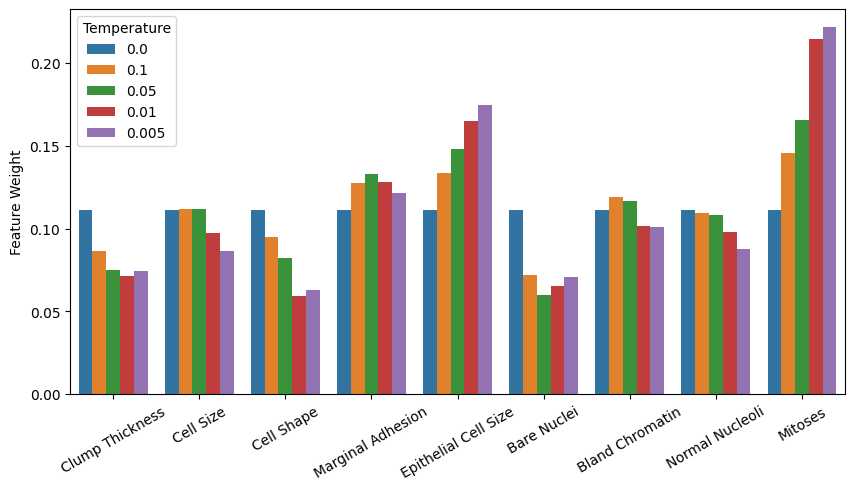

In [40]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=weights_df, x="variable",  y="value", hue="Temperature")
ax.set(xlabel='', ylabel='Feature Weight')
plt.xticks(rotation=30)
            
plt.savefig("diagrams/feature_weights.pdf", bbox_inches='tight')

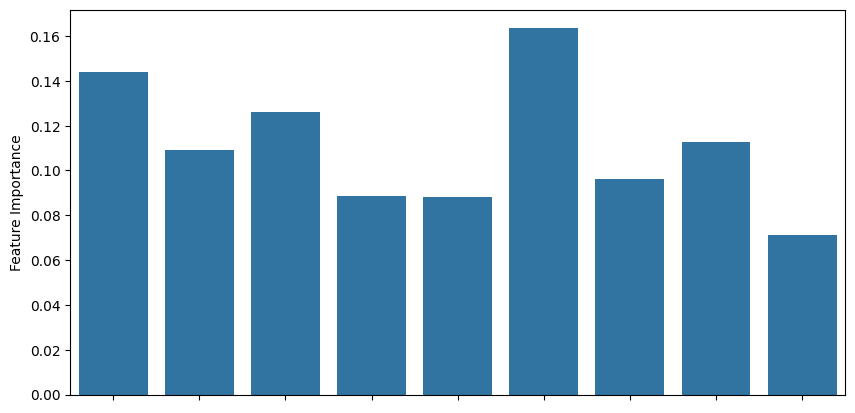

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=importance_df, x="variable", y="value", err_kws={'linewidth': 0})
ax.set(xlabel='', ylabel='Feature Importance', xticklabels=[])
plt.savefig("diagrams/feature_importance.pdf", bbox_inches='tight')